## 1. Imports et Configuration

In [1]:
%matplotlib inline

import sys
import os
import joblib

# Ajouter le répertoire racine au path Python
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Import des transformateurs V3
from src.features.St_Pipeline.Transformateurs import (
    # Loaders
    ImagePathLoader,
    TupleToDataFrame,
    
    # Preprocessing
    ImageResizer,
    ImageAugmenter,
    ImageNormalizer,
    ImageMasker,
    ImageFlattener,
    ImageStandardScaler,
    RGB_to_L,
    
    # Analyse et features
    ImageAnalyser,
    ImagePCA,
    ImageHistogram,
    
    # Utilities
    SaveTransformer,
    TrainTestSplitter,
)

print("✅ Imports réussis!")
print(f"📁 Répertoire de travail: {os.getcwd()}")

✅ Imports réussis!
📁 Répertoire de travail: /home/lena/DS_Covid/DS_COVID/notebooks


## 2. Configuration des Chemins

In [2]:
# Chemins
ROOT_DIR = "/home/lena/DS_Covid/DS_COVID/data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset"
MODELS_DIR = "../models"
OUTPUTS_DIR = "outputs"

# Créer les dossiers
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# Vérification
if os.path.exists(ROOT_DIR):
    print(f"✅ Répertoire trouvé: {ROOT_DIR}")
    labels = [d for d in os.listdir(ROOT_DIR) 
              if os.path.isdir(os.path.join(ROOT_DIR, d, 'images'))]
    print(f"📊 Labels disponibles: {labels}")
    print(f"📊 Nombre de classes: {len(labels)}")
else:
    print(f"❌ Répertoire introuvable: {ROOT_DIR}")

✅ Répertoire trouvé: /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset
📊 Labels disponibles: ['Lung_Opacity', 'Normal', 'COVID', 'Viral Pneumonia']
📊 Nombre de classes: 4


## 3. Pipeline 1: Preprocessing Simple

Pipeline de base pour le preprocessing et la classification.

In [3]:
# ============================================================================
# PIPELINE 1: Chargement et Analyse Métadonnées (SANS chargement images)
# ============================================================================
# But: Scanner le dataset, créer le DataFrame avec paths, analyser métadonnées

pipeline_metadata = Pipeline([
    ('loader', ImagePathLoader(root_dir=ROOT_DIR, verbose=True)),
    ('tuple_to_df', TupleToDataFrame(verbose=True)),
    ('analyzer', ImageAnalyser(load_images=False, analyze_masks=True, verbose=True)),
])

print("\n" + "="*60)
print("🚀 PIPELINE 1: Métadonnées")
print("="*60)

# Exécution: None en entrée car ImagePathLoader scanne ROOT_DIR
df_metadata = pipeline_metadata.fit_transform(None)

print(f"\n✅ Pipeline métadonnées terminé!")
print(f"📊 Dataset complet: {len(df_metadata)} images")
print(f"📋 Colonnes: {list(df_metadata.columns)}")
print(f"\n🔍 Aperçu:")
print(df_metadata.head())



🚀 PIPELINE 1: Métadonnées
[INFO] [ImagePathLoader] Chargement des chemins depuis /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset
[INFO] [ImagePathLoader] Labels trouvés : ['Lung_Opacity', 'Normal', 'COVID', 'Viral Pneumonia']


[ImagePathLoader] Scan labels: 100%|██████████| 4/4 [00:00<00:00, 39.66it/s]



[INFO] [ImagePathLoader] Total chargé : 21165 images
[INFO] [ImagePathLoader] Retour de 21165 chemins
[INFO] [TupleToDataFrame] Conversion de 21165 éléments en DataFrame
[INFO] [TupleToDataFrame] DataFrame créé: 21165 lignes, 3 colonnes
[INFO] [ImageAnalyser] Analyse de 21165 images


[ImageAnalyser] Analyse métadonnées: 100%|██████████| 21165/21165 [00:03<00:00, 6921.85it/s]

[INFO] [ImageAnalyser] Analyse terminée: 1 dimensions uniques
[INFO] [ImageAnalyser] Chargement désactivé, retour du DataFrame original

✅ Pipeline métadonnées terminé!
📊 Dataset complet: 21165 images
📋 Colonnes: ['image_path', 'mask_path', 'label']

🔍 Aperçu:
                                          image_path  \
0  /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19...   
1  /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19...   
2  /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19...   
3  /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19...   
4  /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19...   

                                           mask_path         label  
0  /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19...  lung_opacity  
1  /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19...  lung_opacity  
2  /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19...  lung_opacity  
3  /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19...  lung_opacity  
4  /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19...  lun

## 4. Pipeline 2: Split Train/Test

Séparer le dataset avant le preprocessing lourd.



🚀 PIPELINE 2: Train/Test Split
[INFO] [TrainTestSplitter] Split train/test: 80%/20%
[INFO] [TrainTestSplitter] ✅ Train: 16932 | Test: 4233

📊 Distribution des labels:

Train:
  - covid: 2893 (17.1%)
  - lung_opacity: 4809 (28.4%)
  - normal: 8154 (48.2%)
  - viral pneumonia: 1076 (6.4%)

Test:
  - covid: 723 (17.1%)
  - lung_opacity: 1203 (28.4%)
  - normal: 2038 (48.1%)
  - viral pneumonia: 269 (6.4%)


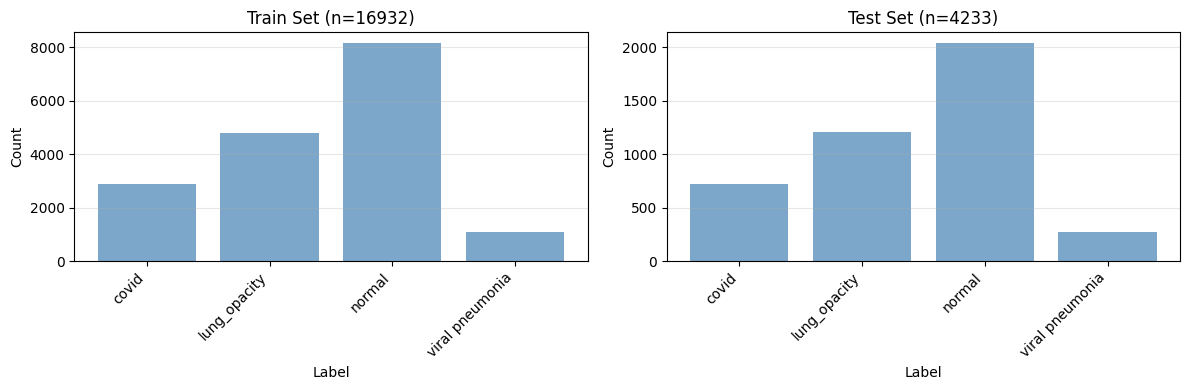


✅ Split terminé!
📊 Train: 16932 images (80.0%)
📊 Test:  4233 images (20.0%)

🏷️ Distribution des labels (train):
label
normal             8154
lung_opacity       4809
covid              2893
viral pneumonia    1076
Name: count, dtype: int64


In [4]:
# ============================================================================
# PIPELINE 2: Train/Test Split
# ============================================================================
# But: Séparer les données AVANT le preprocessing lourd

pipeline_split = Pipeline([
    ('splitter', TrainTestSplitter(test_size=0.2, random_state=42, verbose=True)),
])

print("\n" + "="*60)
print("🚀 PIPELINE 2: Train/Test Split")
print("="*60)

# Exécution sur le DataFrame avec métadonnées
splits = pipeline_split.fit_transform(df_metadata)
df_train = splits['train'][0]  # X_train
y_train = splits['train'][1]
df_test = splits['test'][0]    # X_test
y_test = splits['test'][1]

print(f"\n✅ Split terminé!")
print(f"📊 Train: {len(df_train)} images ({len(df_train)/len(df_metadata)*100:.1f}%)")
print(f"📊 Test:  {len(df_test)} images ({len(df_test)/len(df_metadata)*100:.1f}%)")
print(f"\n🏷️ Distribution des labels (train):")
print(y_train.value_counts())


## 5. Pipeline 3: Preprocessing Images (Train)

Chargement, redimensionnement, normalisation - **sur données TRAIN uniquement**.


In [5]:
# ============================================================================
# PIPELINE 3: Preprocessing Images
# ============================================================================
# But: Charger et preprocesser les images (resize, normalize, grayscale)

pipeline_preprocessing = Pipeline([
    ('analyzer', ImageAnalyser(load_images=True, analyze_masks=False, verbose=True)),
    ('resizer', ImageResizer(img_size=(64, 64), verbose=True)),
    ('normalizer', ImageNormalizer(verbose=True)),
    ('gray', RGB_to_L(verbose=True)),
])

print("\n" + "="*60)
print("🚀 PIPELINE 3: Preprocessing Images")
print("="*60)

# FIT sur TRAIN
print("\n🔹 TRAIN SET:")
df_train_processed = pipeline_preprocessing.fit_transform(df_train)

# TRANSFORM sur TEST (utilise les params appris sur train)
print("\n🔹 TEST SET:")
df_test_processed = pipeline_preprocessing.transform(df_test)

print(f"\n✅ Preprocessing terminé!")
print(f"📊 Train shape: {df_train_processed.shape}")
print(f"📊 Test shape: {df_test_processed.shape}")
print(f"📋 Colonnes ajoutées: {[c for c in df_train_processed.columns if c not in df_train.columns]}")



🚀 PIPELINE 3: Preprocessing Images

🔹 TRAIN SET:
[INFO] [ImageAnalyser] Analyse de 16932 images


[ImageAnalyser] Analyse métadonnées: 100%|██████████| 16932/16932 [00:01<00:00, 10040.03it/s]


[INFO] [ImageAnalyser] Analyse terminée: 1 dimensions uniques
[INFO] [ImageAnalyser] Chargement de 16932 images en mémoire


[ImageAnalyser] Chargement images: 100%|██████████| 16932/16932 [00:24<00:00, 701.67it/s]


[INFO] [ImageAnalyser] Chargement terminé: 16932 images chargées
[INFO] [ImageResizer] Redimensionnement de 16932 images en (64, 64) (DataFrame)


...

[ImageNormalizer] Normalisation: 100%|██████████| 4233/4233 [00:00<00:00, 22141.08it/s]


[INFO] [RGB_to_L] Conversion de 4233 images (DataFrame)


[RGB_to_L] RGB → L: 100%|██████████| 4233/4233 [00:00<00:00, 32808.87it/s]


✅ Preprocessing terminé!
📊 Train shape: (16932, 7)
📊 Test shape: (4233, 7)
📋 Colonnes ajoutées: ['image_array', 'mean_intensity', 'std_intensity', 'channels']



/home/lena/DS_Covid/DS_COVID/.venv/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


## 6. Pipeline 4: Feature Extraction (PCA)

Aplatir les images et réduire la dimension avec PCA.


In [6]:
# ============================================================================
# PIPELINE 4: Feature Extraction avec PCA
# ============================================================================
# But: Aplatir les images et réduire la dimension

pipeline_features_pca = Pipeline([
    ('flattener', ImageFlattener(verbose=True)),
    ('pca', ImagePCA(n_components=50, verbose=True)),
])

print("\n" + "="*60)
print("🔬 PIPELINE 4: Feature Extraction (PCA)")
print("="*60)

# FIT sur TRAIN
print("\n🔹 TRAIN SET:")
X_train_pca = pipeline_features_pca.fit_transform(df_train_processed)

# TRANSFORM sur TEST
print("\n🔹 TEST SET:")
X_test_pca = pipeline_features_pca.transform(df_test_processed)

print(f"\n✅ Features PCA extraites!")
print(f"📊 Train: {X_train_pca.shape}")
print(f"📊 Test: {X_test_pca.shape}")
print(f"📈 Variance expliquée: {pipeline_features_pca.named_steps['pca'].pca.explained_variance_ratio_.sum():.2%}")



🔬 PIPELINE 4: Feature Extraction (PCA)

🔹 TRAIN SET:
[INFO] [ImageFlattener] Aplatissement de 16932 images (DataFrame)


[ImageFlattener] Aplatissement: 100%|██████████| 16932/16932 [00:00<00:00, 27621.80it/s]



[INFO] [ImagePCA] Apprentissage PCA avec 50 composantes sur (16932, 4096)
[INFO] [ImagePCA] PCA fitted. Variance expliquée: 99.73%
[INFO] [ImagePCA] PCA fitted. Variance expliquée: 99.73%
[INFO] [ImagePCA] Application PCA sur (16932, 4096)
[INFO] [ImagePCA] PCA terminé. Shape: (16932, 50)

🔹 TEST SET:
[INFO] [ImageFlattener] Aplatissement de 4233 images (DataFrame)
[INFO] [ImagePCA] Application PCA sur (16932, 4096)
[INFO] [ImagePCA] PCA terminé. Shape: (16932, 50)

🔹 TEST SET:
[INFO] [ImageFlattener] Aplatissement de 4233 images (DataFrame)


[ImageFlattener] Aplatissement: 100%|██████████| 4233/4233 [00:00<00:00, 25693.50it/s]



[INFO] [ImagePCA] Application PCA sur (4233, 4096)
[INFO] [ImagePCA] PCA terminé. Shape: (4233, 50)

✅ Features PCA extraites!
📊 Train: (16932, 50)
📊 Test: (4233, 50)
📈 Variance expliquée: 99.73%


/home/lena/DS_Covid/DS_COVID/.venv/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


## 7. Entraînement du Modèle


In [7]:
print("\n" + "="*60)
print("🤖 Entraînement RandomForest")
print("="*60)

# Modèle
clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Entraînement
clf.fit(X_train_pca, y_train)

print("\n✅ Modèle entraîné!")



🤖 Entraînement RandomForest


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.4s



✅ Modèle entraîné!


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    1.2s finished


## 8. Évaluation


In [8]:
print("\n" + "="*60)
print("📈 Évaluation du Modèle")
print("="*60)

# Prédictions
y_pred = clf.predict(X_test_pca)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Accuracy: {accuracy:.2%}")

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred))



📈 Évaluation du Modèle

🎯 Accuracy: 75.69%

📋 Classification Report:
                 precision    recall  f1-score   support

          covid       0.79      0.41      0.54       723
   lung_opacity       0.70      0.73      0.71      1203
         normal       0.76      0.90      0.83      2038
viral pneumonia       0.93      0.74      0.83       269

       accuracy                           0.76      4233
      macro avg       0.80      0.69      0.73      4233
   weighted avg       0.76      0.76      0.75      4233



[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


## 9. Matrice de Confusion


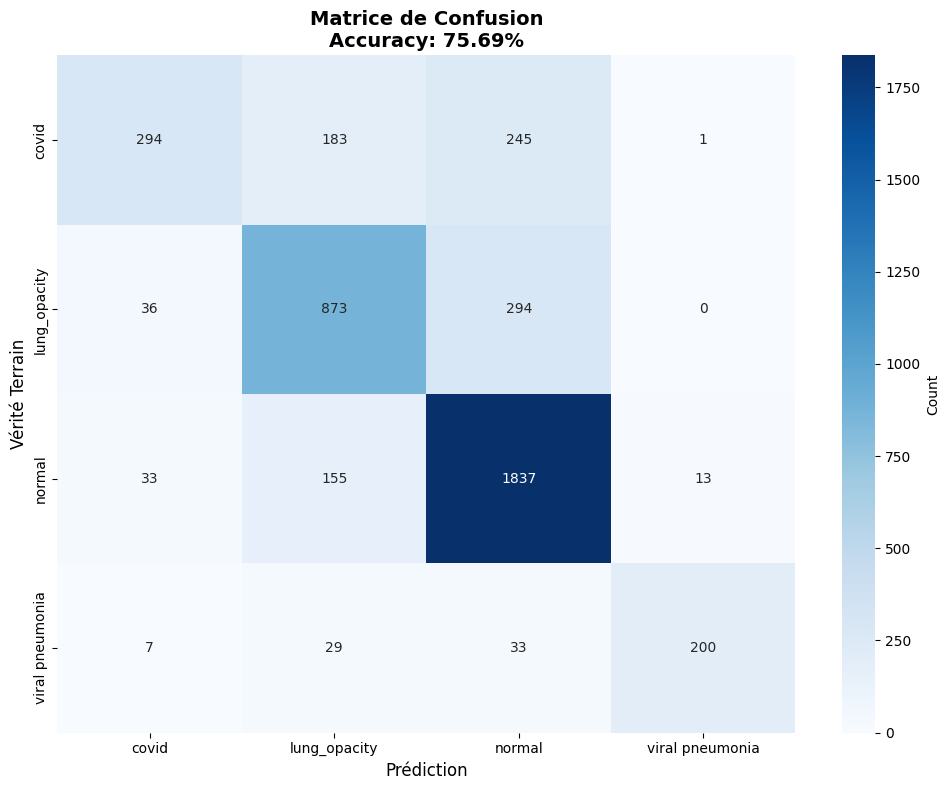

✅ Matrice de confusion affichée!


In [9]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
labels_sorted = sorted(y_test.unique())

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels_sorted, yticklabels=labels_sorted,
            cbar_kws={'label': 'Count'})
plt.xlabel('Prédiction', fontsize=12)
plt.ylabel('Vérité Terrain', fontsize=12)
plt.title(f'Matrice de Confusion\nAccuracy: {accuracy:.2%}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Matrice de confusion affichée!")


## 10. Pipeline Nested Complet (pour Streamlit)

Créer un **nested pipeline** qui combine tout le preprocessing.


In [10]:
# ============================================================================
# NESTED PIPELINE COMPLET (Metadata → Preprocessing → Features PCA)
# ============================================================================
# But: Créer un pipeline tout-en-un pour Streamlit (sans split)

nested_pipeline_complete = Pipeline([
    # Étape 1: Metadata
    ('metadata', pipeline_metadata),
    # Étape 2: Preprocessing
    ('preprocessing', pipeline_preprocessing),
    # Étape 3: Features PCA
    ('features', pipeline_features_pca),
])

print("\n" + "="*60)
print("🔗 NESTED PIPELINE COMPLET")
print("="*60)
print("\n📋 Structure:")
print("  1. Metadata: loader → tuple_to_df → analyzer")
print("  2. Preprocessing: analyzer → resizer → normalizer → gray")
print("  3. Features: flattener → pca")

# Sauvegarder pour Streamlit
nested_path = os.path.join(MODELS_DIR, 'nested_pipeline_complete.pkl')
joblib.dump(nested_pipeline_complete, nested_path)
print(f"\n✅ Nested pipeline sauvegardé: {nested_path}")



🔗 NESTED PIPELINE COMPLET

📋 Structure:
  1. Metadata: loader → tuple_to_df → analyzer
  2. Preprocessing: analyzer → resizer → normalizer → gray
  3. Features: flattener → pca

✅ Nested pipeline sauvegardé: ../models/nested_pipeline_complete.pkl


## 11. Pipeline Alternatif: Histogrammes

Tester une approche alternative avec histogrammes au lieu de PCA.


In [11]:
# ============================================================================
# PIPELINE 5: Feature Extraction avec Histogrammes
# ============================================================================
# But: Alternative à PCA - utiliser des histogrammes d'intensité

pipeline_features_histogram = Pipeline([
    ('histogram', ImageHistogram(bins=32, verbose=True)),
])

print("\n" + "="*60)
print("📊 PIPELINE 5: Feature Extraction (Histogrammes)")
print("="*60)

# FIT sur TRAIN (utilise df_train_processed du pipeline 3)
print("\n🔹 TRAIN SET:")
X_train_hist = pipeline_features_histogram.fit_transform(df_train_processed)

# TRANSFORM sur TEST
print("\n🔹 TEST SET:")
X_test_hist = pipeline_features_histogram.transform(df_test_processed)

print(f"\n✅ Features histogrammes extraites!")
print(f"📊 Train: {X_train_hist.shape}")
print(f"📊 Test: {X_test_hist.shape}")

# Entraîner modèle
print("\n🤖 Entraînement RandomForest sur Histogrammes...")
clf_hist = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
clf_hist.fit(X_train_hist, y_train)

# Évaluation
y_pred_hist = clf_hist.predict(X_test_hist)
accuracy_hist = accuracy_score(y_test, y_pred_hist)

print(f"\n🎯 Accuracy (Histogrammes): {accuracy_hist:.2%}")



📊 PIPELINE 5: Feature Extraction (Histogrammes)

🔹 TRAIN SET:
[INFO] [ImageHistogram] Calcul des histogrammes (32 bins) pour 16932 images


[ImageHistogram] Histogrammes: 100%|██████████| 16932/16932 [00:02<00:00, 6995.04it/s]



🔹 TEST SET:
[INFO] [ImageHistogram] Calcul des histogrammes (32 bins) pour 4233 images


[ImageHistogram] Histogrammes: 100%|██████████| 4233/4233 [00:00<00:00, 6731.14it/s]
/home/lena/DS_Covid/DS_COVID/.venv/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(

/home/lena/DS_Covid/DS_COVID/.venv/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(



✅ Features histogrammes extraites!
📊 Train: (16932, 32)
📊 Test: (4233, 32)

🤖 Entraînement RandomForest sur Histogrammes...

🎯 Accuracy (Histogrammes): 78.64%

🎯 Accuracy (Histogrammes): 78.64%


## 12. Comparaison & Sauvegarde


In [12]:
print("\n" + "="*60)
print("📊 COMPARAISON & SAUVEGARDE")
print("="*60)

# Comparaison
print("\n⚖️ Comparaison des approches:")
print(f"  PCA (50 composantes):      {accuracy:.2%}")
print(f"  Histogrammes (32 bins):    {accuracy_hist:.2%}")

if accuracy > accuracy_hist:
    winner = "PCA"
    diff = (accuracy - accuracy_hist) * 100
else:
    winner = "Histogrammes"
    diff = (accuracy_hist - accuracy) * 100

print(f"\n🏆 Meilleure approche: {winner} (+{diff:.2f}%)")

# Sauvegarder les pipelines individuels
print("\n💾 Sauvegarde des pipelines...")

# Pipeline 1: Metadata only
path1 = os.path.join(MODELS_DIR, 'pipeline_1_metadata.pkl')
joblib.dump(pipeline_metadata, path1)
print(f"  ✅ {path1}")

# Pipeline 2: Split
path2 = os.path.join(MODELS_DIR, 'pipeline_2_split.pkl')
joblib.dump(pipeline_split, path2)
print(f"  ✅ {path2}")

# Pipeline 3: Preprocessing
path3 = os.path.join(MODELS_DIR, 'pipeline_3_preprocessing.pkl')
joblib.dump(pipeline_preprocessing, path3)
print(f"  ✅ {path3}")

# Pipeline 4: PCA
path4 = os.path.join(MODELS_DIR, 'pipeline_4_features_pca.pkl')
joblib.dump(pipeline_features_pca, path4)
print(f"  ✅ {path4}")

# Pipeline 5: Histogrammes
path5 = os.path.join(MODELS_DIR, 'pipeline_5_features_histogram.pkl')
joblib.dump(pipeline_features_histogram, path5)
print(f"  ✅ {path5}")

# Modèles
model_pca_path = os.path.join(MODELS_DIR, 'model_rf_pca.pkl')
joblib.dump(clf, model_pca_path)
print(f"  ✅ {model_pca_path}")

model_hist_path = os.path.join(MODELS_DIR, 'model_rf_histogram.pkl')
joblib.dump(clf_hist, model_hist_path)
print(f"  ✅ {model_hist_path}")

# Nested pipeline pour Streamlit (déjà sauvegardé)
print(f"  ✅ {nested_path}")

print("\n" + "="*60)
print("✅ PIPELINE V3 MAIN TERMINÉ!")
print("="*60)
print(f"\n📊 Résumé:")
print(f"  • Dataset: {len(df_metadata)} images, {len(labels)} classes")
print(f"  • Train/Test: {len(df_train)}/{len(df_test)}")
print(f"  • Best accuracy: {max(accuracy, accuracy_hist):.2%} ({winner})")
print(f"\n🚀 Pipelines prêts pour Streamlit!")



📊 COMPARAISON & SAUVEGARDE

⚖️ Comparaison des approches:
  PCA (50 composantes):      75.69%
  Histogrammes (32 bins):    78.64%

🏆 Meilleure approche: Histogrammes (+2.95%)

💾 Sauvegarde des pipelines...
  ✅ ../models/pipeline_1_metadata.pkl
  ✅ ../models/pipeline_2_split.pkl
  ✅ ../models/pipeline_3_preprocessing.pkl
  ✅ ../models/pipeline_4_features_pca.pkl
  ✅ ../models/pipeline_5_features_histogram.pkl
  ✅ ../models/model_rf_pca.pkl
  ✅ ../models/model_rf_histogram.pkl
  ✅ ../models/nested_pipeline_complete.pkl

✅ PIPELINE V3 MAIN TERMINÉ!

📊 Résumé:
  • Dataset: 21165 images, 4 classes
  • Train/Test: 16932/4233
  • Best accuracy: 78.64% (Histogrammes)

🚀 Pipelines prêts pour Streamlit!
  ✅ ../models/model_rf_histogram.pkl
  ✅ ../models/nested_pipeline_complete.pkl

✅ PIPELINE V3 MAIN TERMINÉ!

📊 Résumé:
  • Dataset: 21165 images, 4 classes
  • Train/Test: 16932/4233
  • Best accuracy: 78.64% (Histogrammes)

🚀 Pipelines prêts pour Streamlit!


## 13. Test Nested Pipeline avec Streamlit Executor

Tester l'affichage récursif des nested pipelines.

In [13]:
# Test de l'exécution du nested pipeline avec affichage récursif
# (Ce code simule ce que fait Streamlit)

from src.utils import StreamlitPipelineExecutor

print("\n" + "="*60)
print("🧪 TEST: Nested Pipeline Executor")
print("="*60)

# Créer un mini nested pipeline pour test
mini_nested = Pipeline([
    ('metadata', Pipeline([
        ('loader', ImagePathLoader(root_dir=ROOT_DIR, verbose=False)),
        ('tuple_to_df', TupleToDataFrame(verbose=False)),
    ])),
    ('preprocessing', Pipeline([
        ('analyzer', ImageAnalyser(load_images=False, verbose=False)),
    ])),
])

print("\n📋 Structure du nested pipeline:")
print("  Level 0: mini_nested")
print("    ├─ metadata (Pipeline)")
print("    │   ├─ loader")
print("    │   └─ tuple_to_df")
print("    └─ preprocessing (Pipeline)")
print("        └─ analyzer")

print("\n⚠️ Note: L'affichage Streamlit complet est visible uniquement dans l'app web")
print("✅ Le code de détection récursive est maintenant implémenté!")
print("\nQuand utilisé dans Streamlit, vous verrez:")
print("  • Expanders pour les nested pipelines")
print("  • Containers pour les transformateurs individuels")
print("  • Progression pour chaque étape")
print("  • Plots et visualisations générés par les transformateurs")

print("\n✅ Import réussi! StreamlitPipelineExecutor prêt à l'emploi.")
print(f"📦 Classe importée: {StreamlitPipelineExecutor}")


2025-12-10 14:50:11.840893: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-10 14:50:11.874596: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-10 14:50:12.873025: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/lena/DS_Covid/DS_COVID/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-12-10 14:50:12.873025: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machin


🧪 TEST: Nested Pipeline Executor

📋 Structure du nested pipeline:
  Level 0: mini_nested
    ├─ metadata (Pipeline)
    │   ├─ loader
    │   └─ tuple_to_df
    └─ preprocessing (Pipeline)
        └─ analyzer

⚠️ Note: L'affichage Streamlit complet est visible uniquement dans l'app web
✅ Le code de détection récursive est maintenant implémenté!

Quand utilisé dans Streamlit, vous verrez:
  • Expanders pour les nested pipelines
  • Containers pour les transformateurs individuels
  • Progression pour chaque étape
  • Plots et visualisations générés par les transformateurs

✅ Import réussi! StreamlitPipelineExecutor prêt à l'emploi.
📦 Classe importée: <class 'src.utils.pipeline_executor.StreamlitPipelineExecutor'>
